In [1]:
'''
Importing data
'''

import pandas as pd
# Load the files
employee_file = 'lat_long.csv'
bus_stop_file = 'Intersection_LatLongs_Modified.csv' #Intersection_LatLongs

# Read the data
employee_data = pd.read_csv(employee_file)
bus_stop_data = pd.read_csv(bus_stop_file)

# Extract latitude and longitude for employee addresses
employee_coords = employee_data[['Longitude', 'Latitude']].dropna().values
# Extract latitude and longitude for bus stop addresses
bus_stop_coords = bus_stop_data[['Longitude', 'Latitude']].dropna().values

In [2]:
print(employee_coords[0:5])
import numpy as np
np.shape(employee_coords)

[[-122.427311     37.727605  ]
 [-122.4159152    37.70439097]
 [-122.4154542    37.76795024]
 [-122.4196762    37.7296632 ]
 [-122.431219     37.7362961 ]]


(2191, 2)

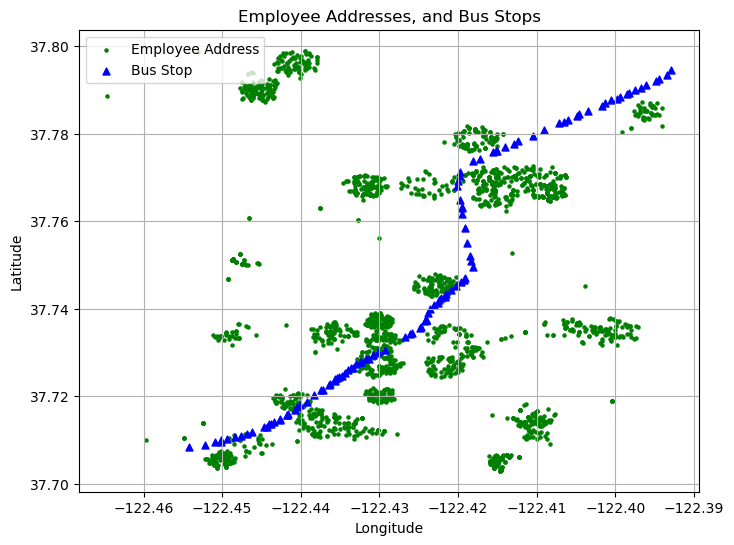

In [3]:
'''
Plotting data for data preprossing and data mining
'''
import matplotlib.pyplot as plt

# Coordinates for the specific location (Mission St, California, USA)
mission_st_coords = (37.7885, -122.3986)

# Plot Employee Residences and Bus Stops
plt.figure(figsize=(8, 6))

# Scatter plot for employee residences
plt.scatter(
    employee_coords[:, 0], employee_coords[:, 1],
    c='green', marker='o', s=5, label='Employee Address'
)

# Scatter plot for bus stops
plt.scatter(
    bus_stop_coords[:, 0], bus_stop_coords[:, 1],
    c='blue', marker='^', s=25, label='Bus Stop'
)

# # Plot the specific location (Mission St)
# plt.scatter(
#     mission_st_coords[0], mission_st_coords[1],
#     c='red', marker='*', s=100, label='Mission St'
# )

# Add labels, legend, and title
plt.title('Employee Addresses, and Bus Stops')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True)
# Save the plot as a JPG file
plt.savefig('employee_bus_stops.jpg', format='jpg', dpi=300)
plt.show()


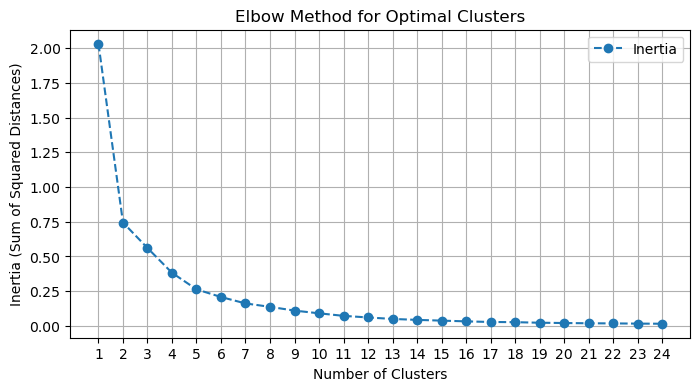

In [4]:
'''
Kmeans clustering and the measures plot to select the optimal centroids
'''
from sklearn.cluster import KMeans
#from mpl_toolkits.mplot3d import Axes3D

import warnings
# Suppress warnings
warnings.filterwarnings("ignore", category=FutureWarning)  # Suppresses future warnings (e.g., n_init default change)
warnings.filterwarnings("ignore", category=UserWarning)    # Suppresses user warnings (e.g., convergence issues)

# Elbow Method for Optimal Clusters with Error Percentage
inertia_values = []
error_percentages = []
cluster_range = range(1, 25)  # Test between 1 and 20 clusters

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(employee_coords)
    inertia_values.append(kmeans.inertia_)

# Calculate error percentages
for i in range(1, len(inertia_values)):
    error = (inertia_values[i - 1] - inertia_values[i]) / inertia_values[i - 1] * 100
    error_percentages.append(error)

# Plot the elbow curve
plt.figure(figsize=(8, 4))
plt.plot(cluster_range, inertia_values, marker='o', linestyle='--', label='Inertia')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.xticks(cluster_range)
plt.grid(True)
plt.legend()
# Save the plot as a JPG file
plt.savefig('Inertia_plot.jpg', format='jpg', dpi=300)
plt.show()

# # Plot error percentage
# plt.figure(figsize=(8, 4))
# plt.plot(cluster_range[1:], error_percentages, marker='o', linestyle='-', color='orange', label='Error Percentage')
# plt.title('Error Percentage Across Clusters')
# plt.xlabel('Number of Clusters')
# plt.ylabel('Error Percentage (%)')
# plt.xticks(cluster_range[1:])
# plt.grid(True)
# plt.legend()
# plt.show()

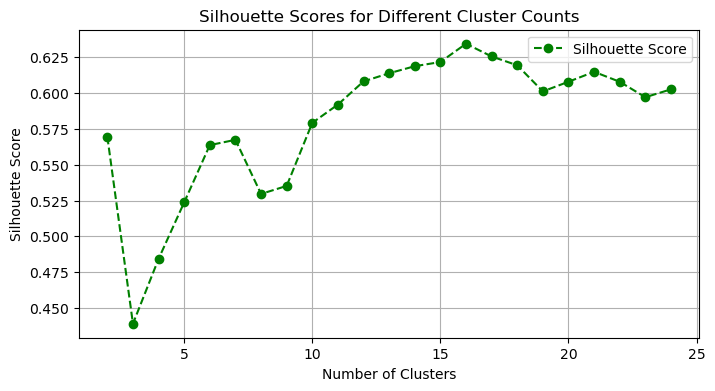

Optimal Number of Clusters (Silhouette Score): 16


In [5]:
'''
Kmeans clustering and the measures plot to select the optimal centroids
'''
from sklearn.metrics import silhouette_score

silhouette_scores = []

# Calculate silhouette scores for different cluster counts
for k in range(2, 25):  # Silhouette requires at least 2 clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(employee_coords)
    score = silhouette_score(employee_coords, kmeans.labels_)
    silhouette_scores.append(score)

# Plot the silhouette scores
plt.figure(figsize=(8, 4))
plt.plot(range(2, 25), silhouette_scores, marker='o', linestyle='--', color='green', label='Silhouette Score')
plt.title('Silhouette Scores for Different Cluster Counts')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.legend()
plt.savefig('Silhouette_plot.jpg', format='jpg', dpi=300)
plt.show()

# Print the optimal number of clusters
optimal_clusters = 2 + silhouette_scores.index(max(silhouette_scores))  # Index + 2 (starting cluster count)
print(f"Optimal Number of Clusters (Silhouette Score): {optimal_clusters}")

Optimal Number of Clusters (based on Davies-Bouldin Index): 16


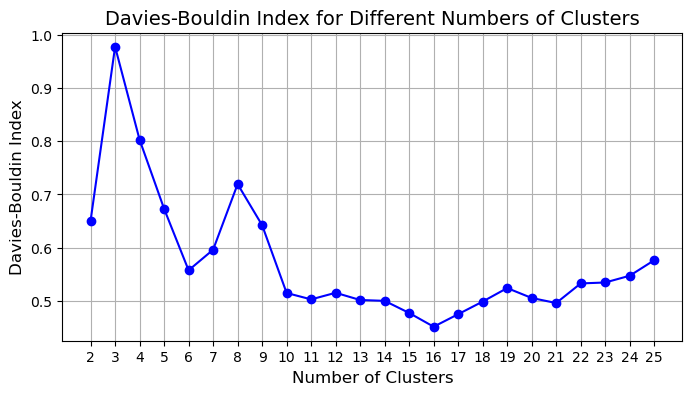

In [6]:
'''
Kmeans clustering and the measures plot to select the optimal centroids
'''
from sklearn.metrics import davies_bouldin_score# Function to calculate the Davies-Bouldin Index for different cluster numbers
def find_optimal_clusters(data, max_clusters=25):
    scores = []
    for n_clusters in range(2, max_clusters + 1):
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        labels = kmeans.fit_predict(data)
        score = davies_bouldin_score(data, labels)
        scores.append((n_clusters, score))
    return scores

# Calculate Davies-Bouldin Index for different cluster numbers
db_scores = find_optimal_clusters(employee_coords, max_clusters=25)
optimal_clusters = min(db_scores, key=lambda x: x[1])[0]

# Print optimal number of clusters
print(f"Optimal Number of Clusters (based on Davies-Bouldin Index): {optimal_clusters}")
# Plot Davies-Bouldin Index scores for cluster evaluation
db_scores_x, db_scores_y = zip(*db_scores)

plt.figure(figsize=(8, 4))
plt.plot(db_scores_x, db_scores_y, marker='o', linestyle='-', color='b')
plt.title('Davies-Bouldin Index for Different Numbers of Clusters', fontsize=14)
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('Davies-Bouldin Index', fontsize=12)
plt.xticks(db_scores_x)
plt.grid()
plt.savefig('Davies-Bouldin_plot.jpg', format='jpg', dpi=300)
plt.show()

In [7]:
'''
Kmeans clustering with the optimal centroid number
'''
from geopy.distance import geodesic

# Choose the optimal number of clusters (adjust based on the elbow plot)
num_clusters = 16

# Perform K-Means clustering on employee coordinates
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
kmeans.fit(employee_coords)

# Get the cluster centers as the proposed bus stop locations
cluster_centers = kmeans.cluster_centers_

In [8]:
cluster_centers

array([[-122.42997464,   37.72415803],
       [-122.41769698,   37.77872364],
       [-122.41026741,   37.71420589],
       [-122.44362535,   37.79247604],
       [-122.44953079,   37.70707783],
       [-122.41211221,   37.76793315],
       [-122.42058206,   37.7298857 ],
       [-122.39609558,   37.78470038],
       [-122.43001618,   37.76765587],
       [-122.42257154,   37.74532569],
       [-122.43162333,   37.7347581 ],
       [-122.40311955,   37.73516324],
       [-122.44877232,   37.7340828 ],
       [-122.41475616,   37.70490031],
       [-122.44787978,   37.75108444],
       [-122.43744039,   37.71502381]])

In [9]:
'''
To find the nearest bus stop to each cluster center by finding the distance with all the other bus stops
and slecting the least distanced bus stop
'''

import numpy as np
def find_nearest_bus_stop(cluster_centers, bus_stop_data):
    nearest_stops = []
    for center in cluster_centers:
        distances = bus_stop_data.apply(
            lambda row: geodesic((center[1], center[0]), (row['Latitude'], row['Longitude'])).miles, axis=1 
        )
        #print(np.size(distances))
        nearest_stop_idx = distances.idxmin()  # Get the index of the nearest stop Latitude
        nearest_stops.append(bus_stop_data.loc[nearest_stop_idx])
    return pd.DataFrame(nearest_stops)

# Find the nearest bus stops for each cluster center
nearest_stops_df = find_nearest_bus_stop(cluster_centers, bus_stop_data)
print(nearest_stops_df)

    Street_One    Street_Two_                             Street_Two  \
51  MISSION ST  EXCELSIOR AVE  EXCELSIOR AVE, San Francisco, CA, USA   
27  MISSION ST        09TH ST         9TH ST, San Francisco, CA, USA   
51  MISSION ST  EXCELSIOR AVE  EXCELSIOR AVE, San Francisco, CA, USA   
70  MISSION ST   LAFAYETTE ST   LAFAYETTE ST, San Francisco, CA, USA   
87  MISSION ST      OLIVER ST      OLIVER ST, San Francisco, CA, USA   
4   MISSION ST        14TH ST        14TH ST, San Francisco, CA, USA   
38  MISSION ST    BOSWORTH ST    BOSWORTH ST, San Francisco, CA, USA   
19  MISSION ST        02ND ST         2ND ST, San Francisco, CA, USA   
4   MISSION ST        14TH ST        14TH ST, San Francisco, CA, USA   
18  MISSION ST        29TH ST        29TH ST, San Francisco, CA, USA   
38  MISSION ST    BOSWORTH ST    BOSWORTH ST, San Francisco, CA, USA   
20  MISSION ST        30TH ST        30TH ST, San Francisco, CA, USA   
47  MISSION ST      COTTER ST      COTTER ST, San Francisco, CA,

In [10]:
# Step 1: Identify unique stops and assign unique IDs (0-11)
unique_stops = nearest_stops_df[['Longitude', 'Latitude']].drop_duplicates().reset_index(drop=True)
unique_stops['Unique_ID'] = range(len(unique_stops))  # Assign IDs from 0 to the number of unique stops

# Step 2: Map unique IDs back to the original nearest_stops_df
nearest_stops_df = nearest_stops_df.merge(unique_stops, on=['Longitude', 'Latitude'], how='left')

# Step 3: Display the updated DataFrame
print(nearest_stops_df[['Longitude', 'Latitude', 'Unique_ID']])
#unique_id= nearest_stops_df['Unique_ID']

     Longitude   Latitude  Unique_ID
0  -122.433348  37.726461          0
1  -122.415024  37.776122          1
2  -122.433348  37.726461          0
3  -122.418068  37.773699          2
4  -122.450097  37.709592          3
5  -122.420084  37.768036          4
6  -122.426808  37.733437          5
7  -122.399852  37.787838          6
8  -122.420084  37.768036          4
9  -122.420837  37.744220          7
10 -122.426808  37.733437          5
11 -122.421722  37.742615          8
12 -122.432974  37.727350          9
13 -122.440708  37.716777         10
14 -122.423125  37.740814         11
15 -122.440708  37.716777         10


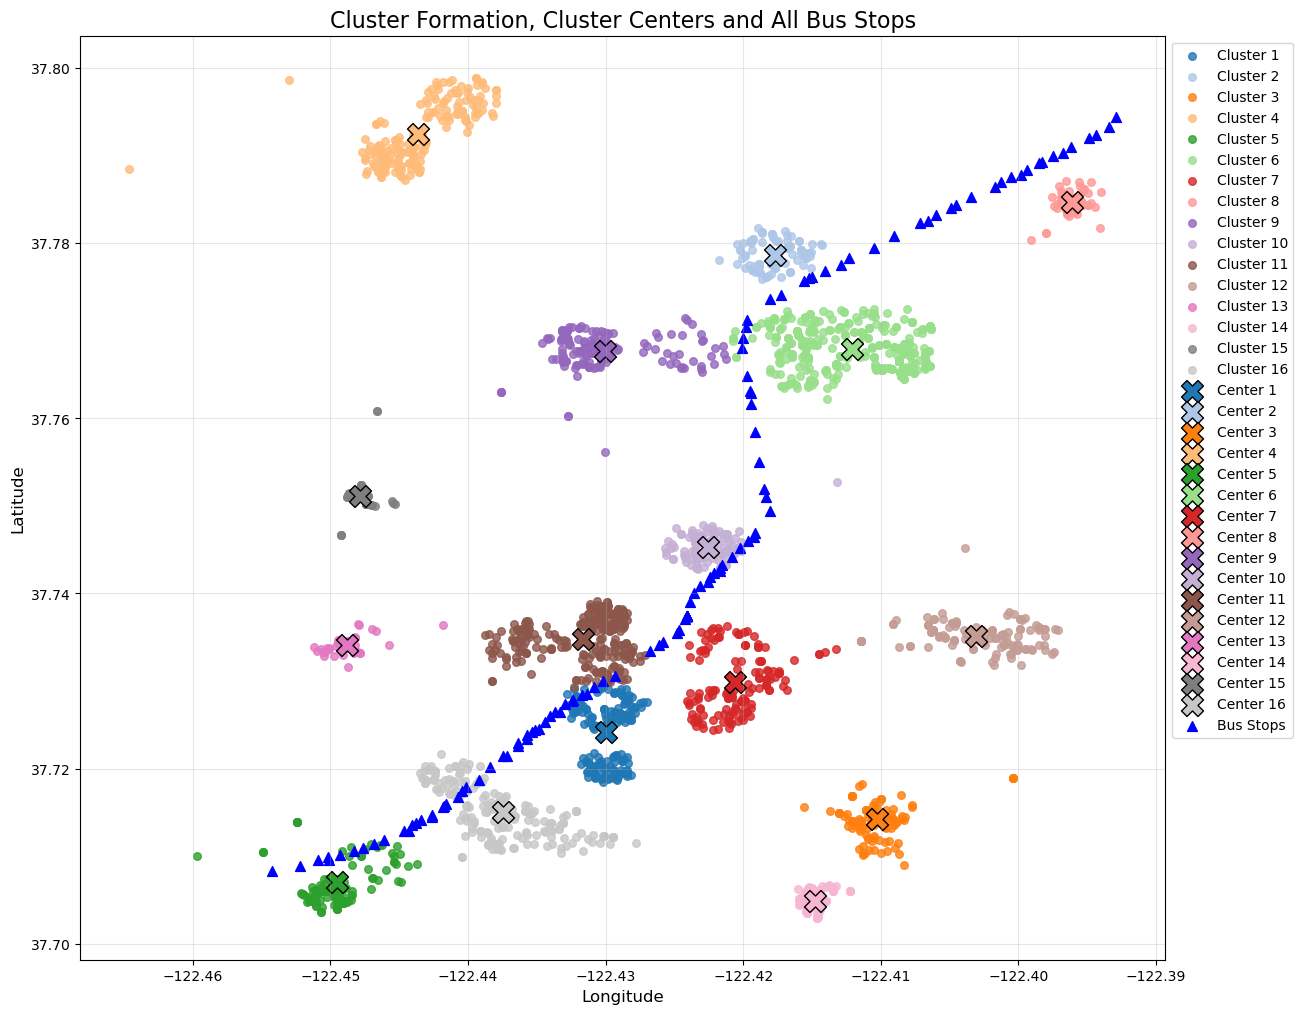

In [11]:
# Plot the clusters, cluster centers
fig, ax = plt.subplots(figsize=(14,12))

# Generate colors for each cluster
colors = plt.cm.tab20(range(num_clusters))

# Scatter plot for employees with transparency to emphasize cluster centers
for cluster_id in range(num_clusters):
    cluster_points = employee_coords[kmeans.labels_ == cluster_id]
    ax.scatter(
        cluster_points[:, 0],  #Longitude
        cluster_points[:, 1],  #Latitude
        c=[colors[cluster_id]], s=30, alpha=0.8, label=f"Cluster {cluster_id+1}"
    )

# Plot cluster centers with larger size, edge color, and unique shape
for cluster_id, center in enumerate(cluster_centers):
    ax.scatter(
        center[0],  
        center[1],  
        c=[colors[cluster_id]], edgecolors='black', marker='X', s=250, label=f"Center {cluster_id+1}"
    )

# Plot all bus stops
ax.scatter(
    bus_stop_coords[:, 0],  
    bus_stop_coords[:, 1],  
    c='blue', marker='^', s=50,  label='Bus Stops'
)

# Add labels, legend, and title
ax.set_title('Cluster Formation, Cluster Centers and All Bus Stops', fontsize=16)
ax.set_xlabel('Longitude', fontsize=12)  # Latitude on x-axis
ax.set_ylabel('Latitude', fontsize=12)  # Longitude on y-axis
plt.legend(fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(alpha=0.3)  # Add a light grid for better visualization
plt.savefig('Cluster&Centroids_plot.jpg', format='jpg', dpi=300)
plt.show()

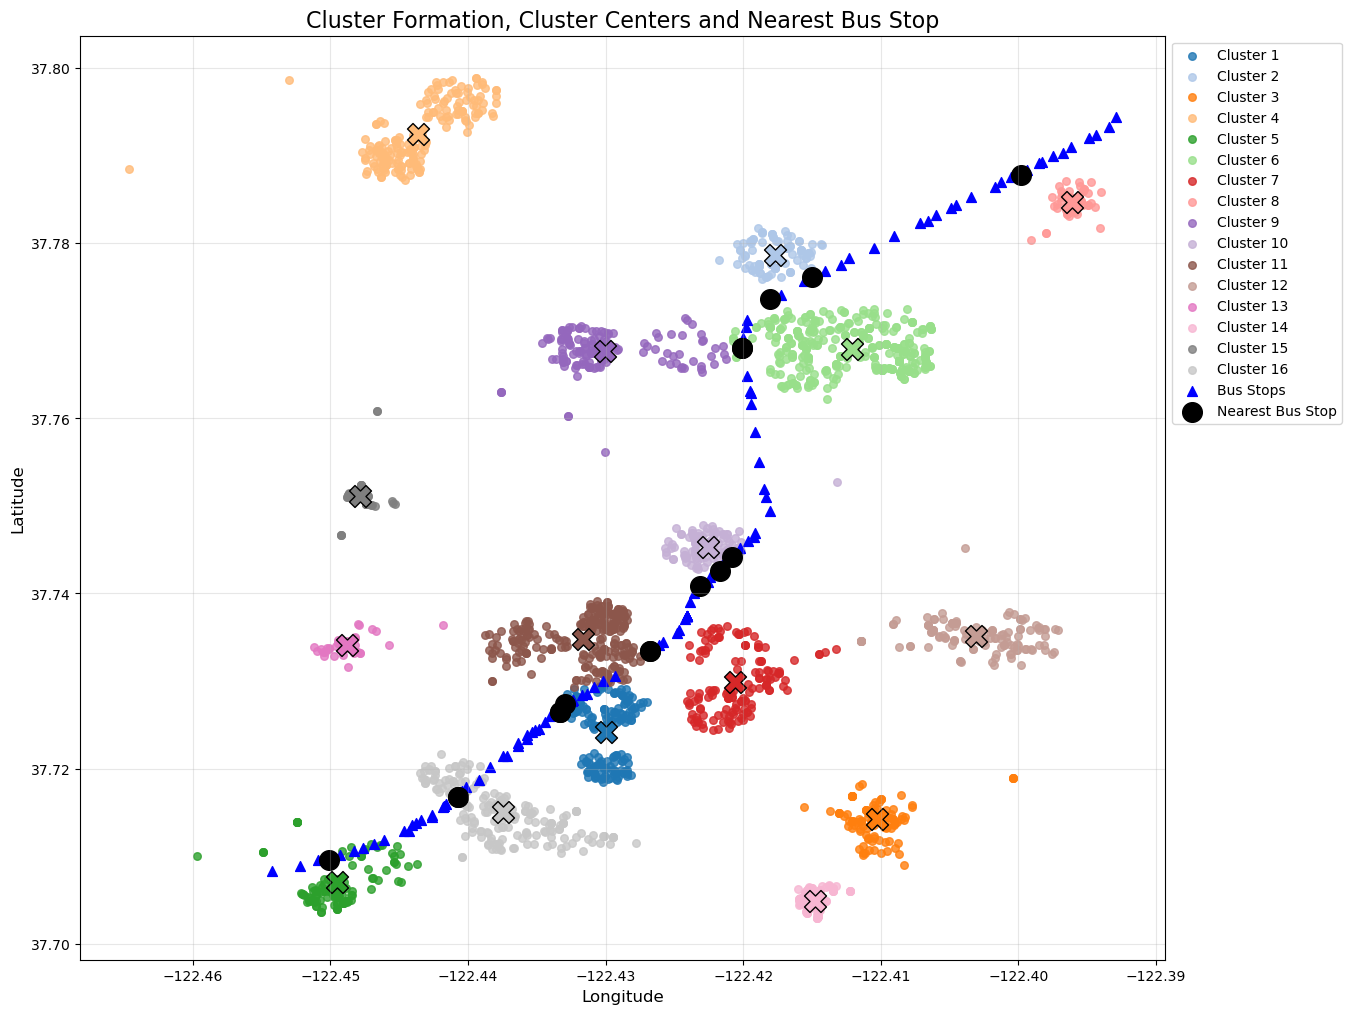

In [13]:
# Plot the clusters, cluster centers and best bus stops
fig, ax = plt.subplots(figsize=(14,12))

# Generate colors for each cluster
colors = plt.cm.tab20(range(num_clusters))

# Scatter plot for employees with transparency to emphasize cluster centers
for cluster_id in range(num_clusters):
    cluster_points = employee_coords[kmeans.labels_ == cluster_id]
    ax.scatter(
        cluster_points[:, 0],  #Longitude
        cluster_points[:, 1],  #Latitude
        c=[colors[cluster_id]], s=30, alpha=0.8, label=f"Cluster {cluster_id+1}"
    )

# Plot cluster centers with larger size, edge color, and unique shape
for cluster_id, center in enumerate(cluster_centers):
    ax.scatter(
        center[0],  
        center[1],  
        c=[colors[cluster_id]], edgecolors='black', marker='X', s=250
    ) #, label=f"Center {cluster_id+1}"

# Plot all bus stops
ax.scatter(
    bus_stop_coords[:, 0],  
    bus_stop_coords[:, 1],  
    c='blue', marker='^', s=50,  label='Bus Stops'
)

# plot nearest bus stops
ax.scatter(
    nearest_stops_df['Longitude'], nearest_stops_df['Latitude'],  
    c='Black', marker='o', s=200, label='Nearest Bus Stop'
)
# Add labels, legend, and title
ax.set_title('Cluster Formation, Cluster Centers and Nearest Bus Stop', fontsize=16)
ax.set_xlabel('Longitude', fontsize=12)  # Latitude on x-axis
ax.set_ylabel('Latitude', fontsize=12)  # Longitude on y-axis
plt.legend(fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(alpha=0.3)  # Add a light grid for better visualization
plt.savefig('NearestBusStops_plot.jpg', format='jpg', dpi=300)
plt.show()

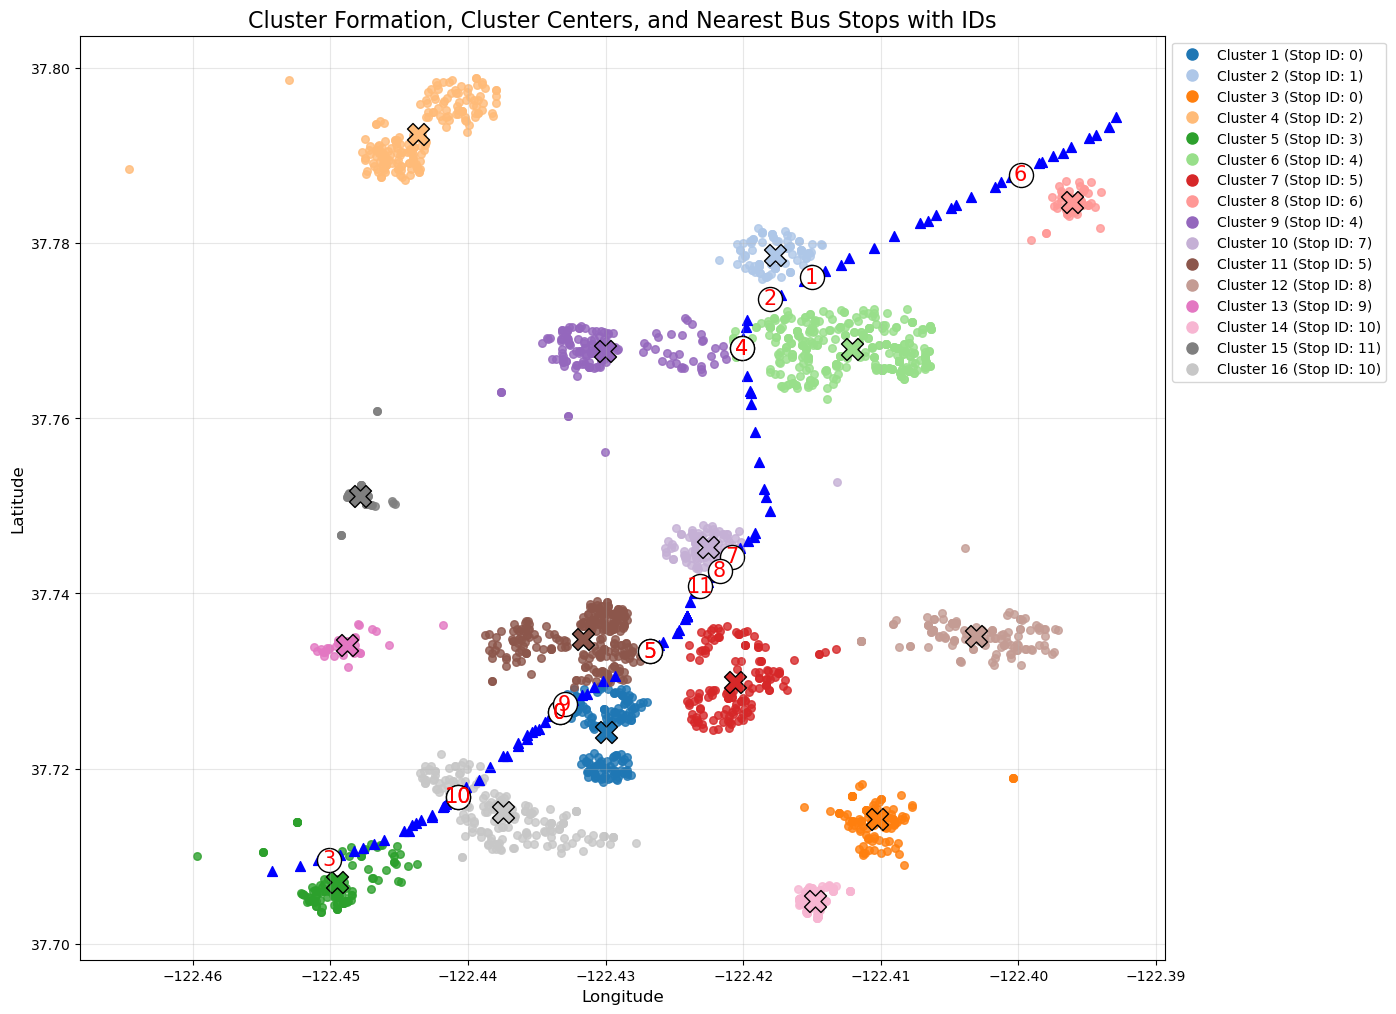

In [14]:
# plot with bus number assined +1 
import matplotlib.lines as mlines

# Plot the clusters, cluster centers, and nearest bus stops
fig, ax = plt.subplots(figsize=(14, 12))

# Generate colors for each cluster
colors = plt.cm.tab20(range(num_clusters))

# Scatter plot for employees with transparency to emphasize cluster centers
for cluster_id in range(num_clusters):
    cluster_points = employee_coords[kmeans.labels_ == cluster_id]
    ax.scatter(
        cluster_points[:, 0],  # Longitude
        cluster_points[:, 1],  # Latitude
        c=[colors[cluster_id]], s=30, alpha=0.8
    )

# Add legend entries for clusters and unique bus stop IDs
legend_handles = []
for cluster_id in range(num_clusters):
    cluster_legend = mlines.Line2D(
        [], [], color=colors[cluster_id], marker='o', linestyle='None',
        markersize=8, label=f"Cluster {cluster_id+1} (Stop ID: {nearest_stops_df.loc[cluster_id, 'Unique_ID']})"
    )
    legend_handles.append(cluster_legend)

# Plot cluster centers with larger size, edge color, and unique shape
for cluster_id, center in enumerate(cluster_centers):
    ax.scatter(
        center[0],
        center[1],
        c=[colors[cluster_id]], edgecolors='black', marker='X', s=250
    )

# Plot all bus stops
ax.scatter(
    bus_stop_coords[:, 0],
    bus_stop_coords[:, 1],
    c='blue', marker='^', s=50, label='Bus Stops'
)

# Plot nearest bus stops with numbering and a black outline
for idx, stop in nearest_stops_df.iterrows():
    ax.scatter(
        stop['Longitude'], stop['Latitude'],
        facecolors='white', edgecolors='black', marker='o', s=300
    )
    # Add numbers inside the nearest bus stop markers
    ax.text(
        stop['Longitude'], stop['Latitude'],
        f"{int(stop['Unique_ID'])}",
        fontsize=15, ha='center', va='center', color='red'
    )

# Add the legend with clusters and bus stop IDs
ax.legend(handles=legend_handles, fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))

# Add title, labels, and grid
ax.set_title('Cluster Formation, Cluster Centers, and Nearest Bus Stops with IDs', fontsize=16)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
plt.grid(alpha=0.3)

# Save and display the plot
plt.savefig('NearestBusStops_with_IDs_and_Legends.jpg', format='jpg', dpi=300)
plt.show()


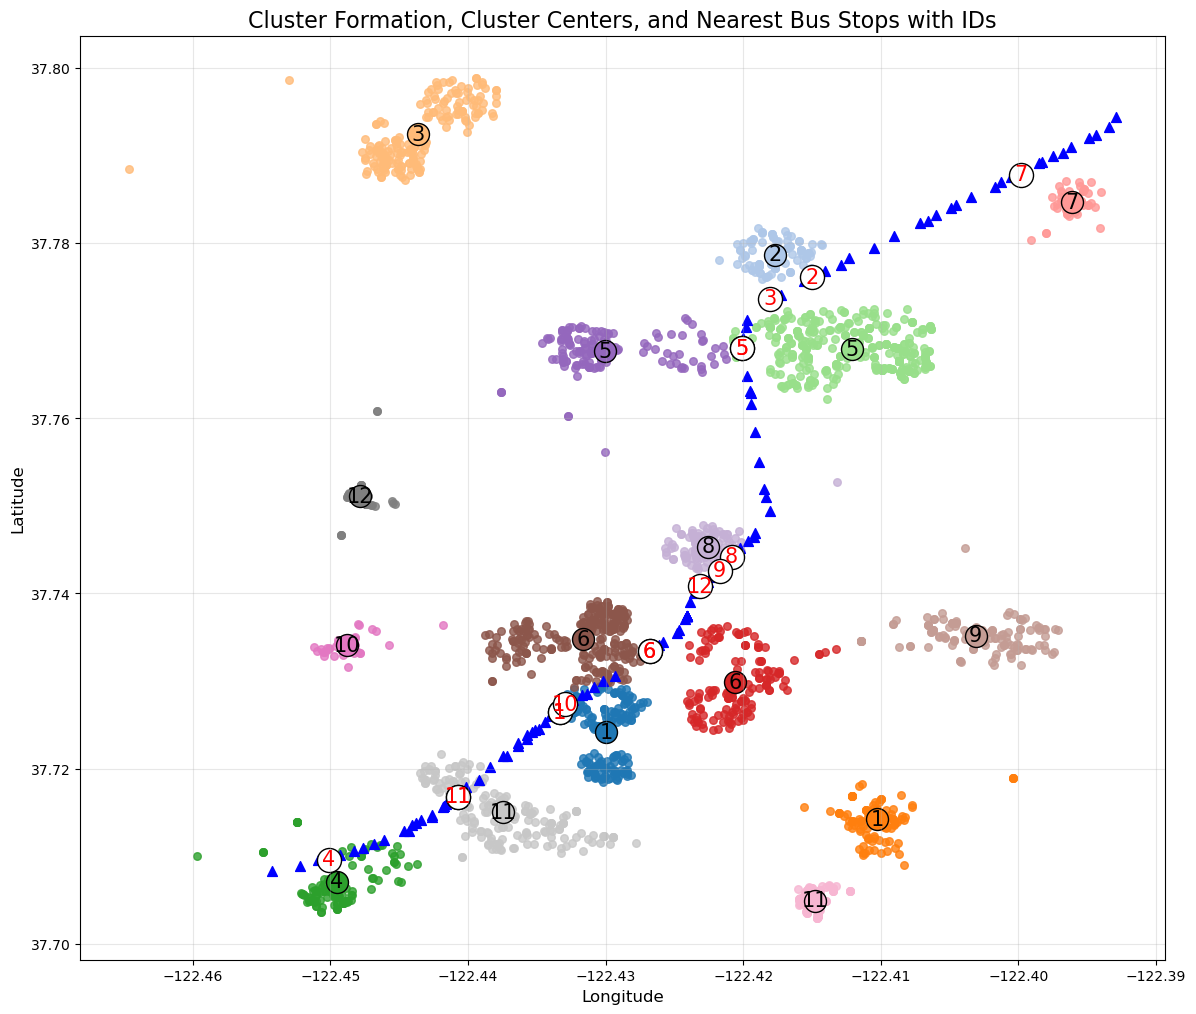

In [15]:
import matplotlib.lines as mlines

# Plot the clusters, cluster centers, and nearest bus stops
fig, ax = plt.subplots(figsize=(14, 12))

# Generate colors for each cluster
colors = plt.cm.tab20(range(num_clusters))

# Scatter plot for employees with transparency to emphasize cluster centers
for cluster_id in range(num_clusters):
    cluster_points = employee_coords[kmeans.labels_ == cluster_id]
    ax.scatter(
        cluster_points[:, 0],  # Longitude
        cluster_points[:, 1],  # Latitude
        c=[colors[cluster_id]], s=30, alpha=0.8
    )

# Add legend entries for clusters and unique bus stop IDs
legend_handles = []
for cluster_id in range(num_clusters):
    cluster_legend = mlines.Line2D(
        [], [], color=colors[cluster_id], marker='o', linestyle='None',
        markersize=8, label=f"Cluster {cluster_id+1} (Stop ID: {nearest_stops_df.loc[cluster_id, 'Unique_ID']})"
    )
    legend_handles.append(cluster_legend)

# Plot cluster centers with larger size, edge color, and unique shape
for cluster_id, center in enumerate(cluster_centers):
    ax.scatter(
        center[0],
        center[1],
        c=[colors[cluster_id]], edgecolors='black', marker='o', s=250
    )
    # Add Stop ID beside the cluster center markers
    stop_id = 1+ nearest_stops_df.loc[cluster_id, 'Unique_ID']
    ax.text(
        center[0] ,  # Slightly offset on the x-axis
        center[1],  # Same y-coordinate
        f"{stop_id}",
        fontsize=15, ha='center', va='center', color='black'
    )

# Plot all bus stops
ax.scatter(
    bus_stop_coords[:, 0],
    bus_stop_coords[:, 1],
    c='blue', marker='^', s=50, label='Bus Stops'
)

# Plot nearest bus stops with numbering and a black outline
for idx, stop in nearest_stops_df.iterrows():
    ax.scatter(
        stop['Longitude'], stop['Latitude'],
        facecolors='white', edgecolors='black', marker='o', s=300
    )
    # Add numbers inside the nearest bus stop markers
    ax.text(
        stop['Longitude'], stop['Latitude'],
        f"{1+int(stop['Unique_ID'])}",
        fontsize=15, ha='center', va='center', color='red'
    )

# Add the legend with clusters and bus stop IDs
#ax.legend(handles=legend_handles, fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))

# Add title, labels, and grid
ax.set_title('Cluster Formation, Cluster Centers, and Nearest Bus Stops with IDs', fontsize=16)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
plt.grid(alpha=0.3)

# Save and display the plot
plt.savefig('NearestBusStops_with_IDs_and_CenterLabels.jpg', format='jpg', dpi=300)
plt.show()


In [16]:
# Find the unique rows in nearest_stops_df
unique_nearest_stops = nearest_stops_df.drop_duplicates()
print(unique_nearest_stops)

    Street_One    Street_Two_                             Street_Two  \
0   MISSION ST  EXCELSIOR AVE  EXCELSIOR AVE, San Francisco, CA, USA   
1   MISSION ST        09TH ST         9TH ST, San Francisco, CA, USA   
3   MISSION ST   LAFAYETTE ST   LAFAYETTE ST, San Francisco, CA, USA   
4   MISSION ST      OLIVER ST      OLIVER ST, San Francisco, CA, USA   
5   MISSION ST        14TH ST        14TH ST, San Francisco, CA, USA   
6   MISSION ST    BOSWORTH ST    BOSWORTH ST, San Francisco, CA, USA   
7   MISSION ST        02ND ST         2ND ST, San Francisco, CA, USA   
9   MISSION ST        29TH ST        29TH ST, San Francisco, CA, USA   
11  MISSION ST        30TH ST        30TH ST, San Francisco, CA, USA   
12  MISSION ST      COTTER ST      COTTER ST, San Francisco, CA, USA   
13  MISSION ST     GENEVA AVE     GENEVA AVE, San Francisco, CA, USA   
14  MISSION ST       BROOK ST       BROOK ST, San Francisco, CA, USA   

             City       State Country   Latitude   Longitude  U

In [17]:
# def optimize_bus_stops_iteratively(cluster_centers, bus_stop_data, max_stops=10):
#     # Step 1: Find the nearest bus stop for each cluster center
#     nearest_stops = []
#     for center in cluster_centers:
#         distances = bus_stop_data.apply(
#             lambda row: geodesic((center[1], center[0]), (row['Latitude'], row['Longitude'])).miles, axis=1
#         )
#         nearest_stop_idx = distances.idxmin()  # Get the index of the nearest stop
#         nearest_stops.append(bus_stop_data.loc[nearest_stop_idx])

#     # Step 2: Convert nearest stops into a DataFrame
#     nearest_stops_df = pd.DataFrame(nearest_stops).drop_duplicates()

#     # Step 3: Iterative removal of redundant stops
#     while len(nearest_stops_df) > max_stops:
#         # Compute pairwise distances between all stops
#         stop_coords = nearest_stops_df[['Latitude', 'Longitude']].values
#         pairwise_distances = pd.DataFrame(
#             [[geodesic(stop_coords[i], stop_coords[j]).miles for j in range(len(stop_coords))]
#              for i in range(len(stop_coords))],
#             columns=nearest_stops_df.index, index=nearest_stops_df.index
#         )

#         # Identify the closest pair of stops
#         pairwise_distances = pairwise_distances.replace(0, float('inf'))  # Replace self-distances with inf
#         closest_pair = pairwise_distances.stack().idxmin()  # Get the indices of the closest pair
#         stop_to_remove = closest_pair[1]  # Select one stop to remove from the closest pair

#         # Remove the stop and ensure clusters are still served
#         nearest_stops_df = nearest_stops_df.drop(stop_to_remove)

#     return nearest_stops_df

# # Optimize the stops to 10
# optimized_stops_df = optimize_bus_stops_iteratively(cluster_centers, bus_stop_data, max_stops=10)

# # Display the optimized stops
# print(optimized_stops_df)

def optimize_bus_stops_with_centers(cluster_centers, bus_stop_data, max_stops=10):
    # Step 1: Find the nearest bus stop for each cluster center
    nearest_stops = []
    for center in cluster_centers:
        distances = bus_stop_data.apply(
            lambda row: geodesic((center[1], center[0]), (row['Latitude'], row['Longitude'])).miles, axis=1
        )
        nearest_stop_idx = distances.idxmin()  # Get the index of the nearest stop
        nearest_stops.append(bus_stop_data.loc[nearest_stop_idx])

    # Step 2: Convert nearest stops into a DataFrame
    nearest_stops_df = pd.DataFrame(nearest_stops).drop_duplicates()

    # Step 3: Iteratively reduce stops
    while len(nearest_stops_df) > max_stops:
        # Compute pairwise distances between all stops
        stop_coords = nearest_stops_df[['Latitude', 'Longitude']].values
        pairwise_distances = pd.DataFrame(
            [[geodesic(stop_coords[i], stop_coords[j]).miles for j in range(len(stop_coords))]
             for i in range(len(stop_coords))],
            columns=nearest_stops_df.index, index=nearest_stops_df.index
        )

        # Identify the closest pair of stops
        pairwise_distances = pairwise_distances.replace(0, float('inf'))  # Replace self-distances with inf
        closest_pair = pairwise_distances.stack().idxmin()  # Get the indices of the closest pair

        # Calculate distances to cluster centers for both stops in the pair
        stop_a_idx, stop_b_idx = closest_pair
        stop_a = nearest_stops_df.loc[stop_a_idx]
        stop_b = nearest_stops_df.loc[stop_b_idx]

        # Determine which stop to remove based on distance to cluster centers
        dist_to_center_a = min([geodesic((center[1], center[0]), (stop_a['Latitude'], stop_a['Longitude'])).miles for center in cluster_centers])
        dist_to_center_b = min([geodesic((center[1], center[0]), (stop_b['Latitude'], stop_b['Longitude'])).miles for center in cluster_centers])

        if dist_to_center_a > dist_to_center_b:
            stop_to_remove = stop_a_idx
        else:
            stop_to_remove = stop_b_idx

        # Remove the stop
        nearest_stops_df = nearest_stops_df.drop(stop_to_remove)

    return nearest_stops_df

# Example: Optimize the stops to 10 using cluster centers
optimized_stops_df = optimize_bus_stops_with_centers(cluster_centers, bus_stop_data, max_stops=10)

# Display the optimized stops
#print(optimized_stops_df)

# Map the Unique_IDs from nearest_stops_df to optimized_stops_df based on Longitude and Latitude
optimized_stops_df['Bus_ID'] = optimized_stops_df.apply(
    lambda row: nearest_stops_df.loc[
        (nearest_stops_df['Longitude'] == row['Longitude']) & 
        (nearest_stops_df['Latitude'] == row['Latitude']),
        'Unique_ID'
    ].values[0], axis=1
)

# Display the updated DataFrame
print(optimized_stops_df[['Longitude', 'Latitude', 'Street_Two_','Bus_ID']])

# Update the nearest_stops_df
nearest_stops_df.loc[11, 'Unique_ID'] = 7
nearest_stops_df.loc[12, 'Unique_ID'] = 0

print(optimized_stops_df['Street_Two_'])

     Longitude   Latitude    Street_Two_  Bus_ID
51 -122.433348  37.726461  EXCELSIOR AVE       0
27 -122.415024  37.776122        09TH ST       1
70 -122.418068  37.773699   LAFAYETTE ST       2
87 -122.450097  37.709592      OLIVER ST       3
4  -122.420084  37.768036        14TH ST       4
38 -122.426808  37.733437    BOSWORTH ST       5
19 -122.399852  37.787838        02ND ST       6
18 -122.420837  37.744220        29TH ST       7
59 -122.440708  37.716777     GENEVA AVE      10
40 -122.423125  37.740814       BROOK ST      11
51    EXCELSIOR AVE
27          09TH ST
70     LAFAYETTE ST
87        OLIVER ST
4           14TH ST
38      BOSWORTH ST
19          02ND ST
18          29TH ST
59       GENEVA AVE
40         BROOK ST
Name: Street_Two_, dtype: object


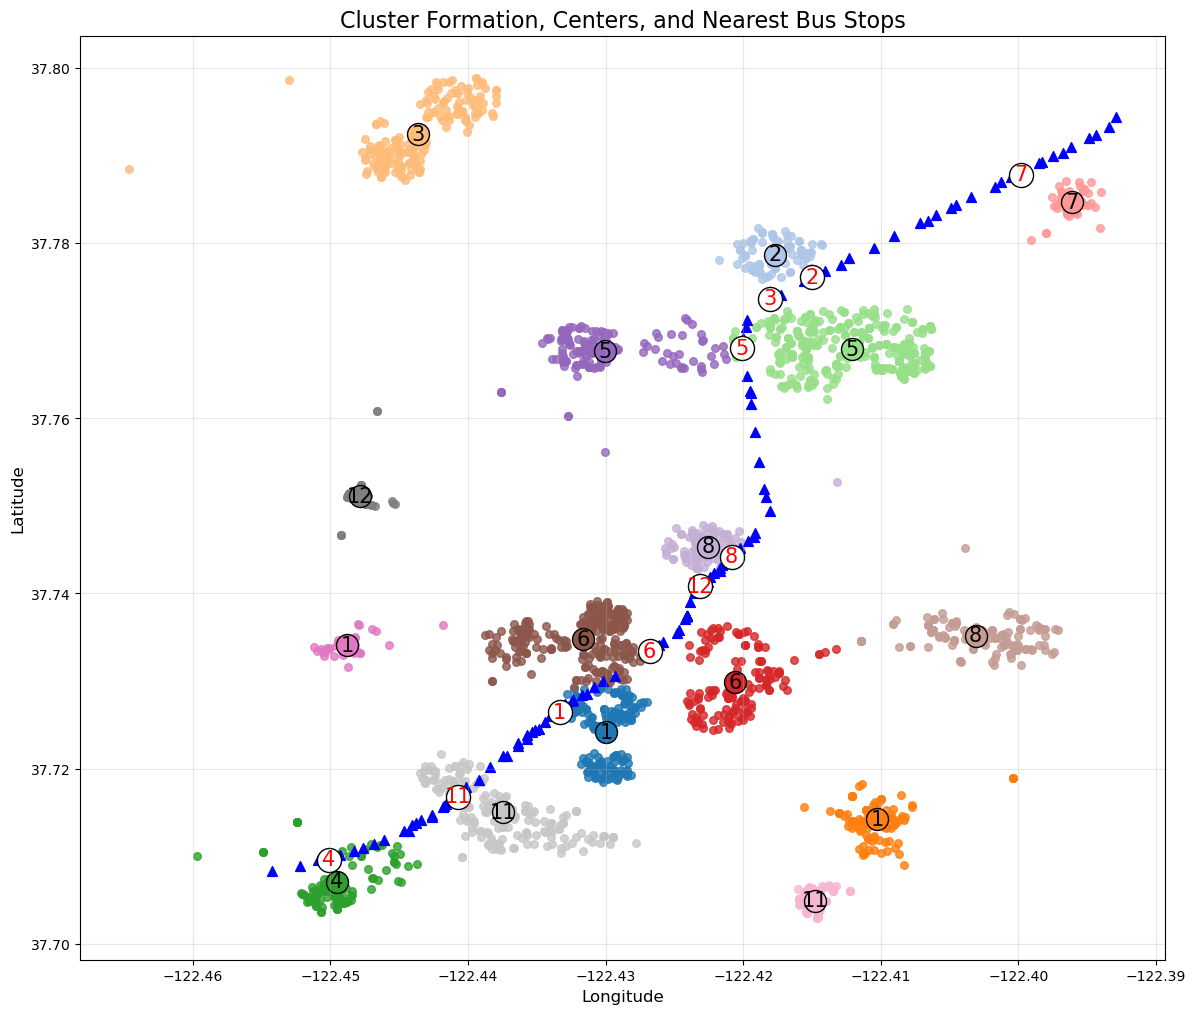

In [19]:
# Plot the clusters, cluster centers, and nearest bus stops
fig, ax = plt.subplots(figsize=(14, 12))

# Generate colors for each cluster
colors = plt.cm.tab20(range(num_clusters))

# Scatter plot for employees with transparency to emphasize cluster centers
for cluster_id in range(num_clusters):
    cluster_points = employee_coords[kmeans.labels_ == cluster_id]
    ax.scatter(
        cluster_points[:, 0],  # Longitude
        cluster_points[:, 1],  # Latitude
        c=[colors[cluster_id]], s=30, alpha=0.8
    )

# Add legend entries for clusters and unique bus stop IDs
legend_handles = []
for cluster_id in range(num_clusters):
    cluster_legend = mlines.Line2D(
        [], [], color=colors[cluster_id], marker='o', linestyle='None',
        markersize=8, label=f"Cluster {cluster_id+1} (Stop ID: {nearest_stops_df.loc[cluster_id, 'Unique_ID']})"
    )
    legend_handles.append(cluster_legend)

# Plot cluster centers with larger size, edge color, and unique shape
for cluster_id, center in enumerate(cluster_centers):
    ax.scatter(
        center[0],
        center[1],
        c=[colors[cluster_id]], edgecolors='black', marker='o', s=250
    )
    # Add Stop ID beside the cluster center markers
    stop_id = 1+ nearest_stops_df.loc[cluster_id, 'Unique_ID']
    ax.text(
        center[0] ,  # Slightly offset on the x-axis
        center[1],  # Same y-coordinate
        f"{stop_id}",
        fontsize=15, ha='center', va='center', color='black'
    )

# Plot all bus stops
ax.scatter(
    bus_stop_coords[:, 0],
    bus_stop_coords[:, 1],
    c='blue', marker='^', s=50, label='Bus Stops'
)

# plot nearest bus stops
for idx, stop in optimized_stops_df.iterrows():
    ax.scatter(
        stop['Longitude'], stop['Latitude'],
        facecolors='white', edgecolors='black', marker='o', s=300
    )
    # Add numbers inside the nearest bus stop markers
    ax.text(
        stop['Longitude'], stop['Latitude'],
        f"{1+int(stop['Bus_ID'])}",
        fontsize=15, ha='center', va='center', color='red'
    )

# ax.scatter(
#     optimized_stops_df['Longitude'], optimized_stops_df['Latitude'],  
#     c='blue', marker='^', s=100, label='Nearest Bus Stops'
# )
# Add labels, legend, and title
ax.set_title('Cluster Formation, Centers, and Nearest Bus Stops', fontsize=16)
ax.set_xlabel('Longitude', fontsize=12)  # Latitude on x-axis
ax.set_ylabel('Latitude', fontsize=12)  # Longitude on y-axis
#plt.legend(fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(alpha=0.3)  # Add a light grid for better visualization
plt.savefig('OptimalBusStops.jpg', format='jpg', dpi=300)
plt.show()


In [20]:
print(optimized_stops_df)

    Street_One    Street_Two_                             Street_Two  \
51  MISSION ST  EXCELSIOR AVE  EXCELSIOR AVE, San Francisco, CA, USA   
27  MISSION ST        09TH ST         9TH ST, San Francisco, CA, USA   
70  MISSION ST   LAFAYETTE ST   LAFAYETTE ST, San Francisco, CA, USA   
87  MISSION ST      OLIVER ST      OLIVER ST, San Francisco, CA, USA   
4   MISSION ST        14TH ST        14TH ST, San Francisco, CA, USA   
38  MISSION ST    BOSWORTH ST    BOSWORTH ST, San Francisco, CA, USA   
19  MISSION ST        02ND ST         2ND ST, San Francisco, CA, USA   
18  MISSION ST        29TH ST        29TH ST, San Francisco, CA, USA   
59  MISSION ST     GENEVA AVE     GENEVA AVE, San Francisco, CA, USA   
40  MISSION ST       BROOK ST       BROOK ST, San Francisco, CA, USA   

             City       State Country   Latitude   Longitude  Bus_ID  
51  San Francisco  California     USA  37.726461 -122.433348       0  
27  San Francisco  California     USA  37.776122 -122.415024     

In [21]:
from sklearn.cluster import AgglomerativeClustering

def optimize_bus_stops(cluster_centers, bus_stop_data, max_stops=10):
    # Step 1: Find the nearest bus stop for each cluster center
    nearest_stops = []
    for center in cluster_centers:
        distances = bus_stop_data.apply(
            lambda row: geodesic((center[1], center[0]), (row['Latitude'], row['Longitude'])).miles, axis=1
        )
        nearest_stop_idx = distances.idxmin()  # Get the index of the nearest stop
        nearest_stops.append(bus_stop_data.loc[nearest_stop_idx])

    # Step 2: Convert nearest stops into a DataFrame
    nearest_stops_df = pd.DataFrame(nearest_stops).drop_duplicates()

    # Step 3: If the number of unique stops exceeds the max_stops, merge stops
    if len(nearest_stops_df) > max_stops:
        # Use hierarchical clustering to group stops into `max_stops` clusters
        stop_coords = nearest_stops_df[['Latitude', 'Longitude']].values
        clustering = AgglomerativeClustering(n_clusters=max_stops, linkage='single')
        clustering.fit(stop_coords)

        # Assign each stop to a cluster
        nearest_stops_df['Cluster'] = clustering.labels_

        # Take the first stop from each cluster as the representative stop
        optimized_stops = nearest_stops_df.groupby('Cluster').first().reset_index()
    else:
        # If already within limit, return the unique stops
        optimized_stops = nearest_stops_df

    return optimized_stops

# Optimize the stops to 10
optimized_stops_df = optimize_bus_stops(cluster_centers, bus_stop_data, max_stops=10)

# Display the optimized stops
print(optimized_stops_df) 

   Cluster  Street_One    Street_Two_                             Street_Two  \
0        0  MISSION ST        29TH ST        29TH ST, San Francisco, CA, USA   
1        1  MISSION ST       BROOK ST       BROOK ST, San Francisco, CA, USA   
2        2  MISSION ST  EXCELSIOR AVE  EXCELSIOR AVE, San Francisco, CA, USA   
3        3  MISSION ST        02ND ST         2ND ST, San Francisco, CA, USA   
4        4  MISSION ST     GENEVA AVE     GENEVA AVE, San Francisco, CA, USA   
5        5  MISSION ST        09TH ST         9TH ST, San Francisco, CA, USA   
6        6  MISSION ST    BOSWORTH ST    BOSWORTH ST, San Francisco, CA, USA   
7        7  MISSION ST        14TH ST        14TH ST, San Francisco, CA, USA   
8        8  MISSION ST   LAFAYETTE ST   LAFAYETTE ST, San Francisco, CA, USA   
9        9  MISSION ST      OLIVER ST      OLIVER ST, San Francisco, CA, USA   

            City       State Country   Latitude   Longitude  
0  San Francisco  California     USA  37.744220 -122.4208

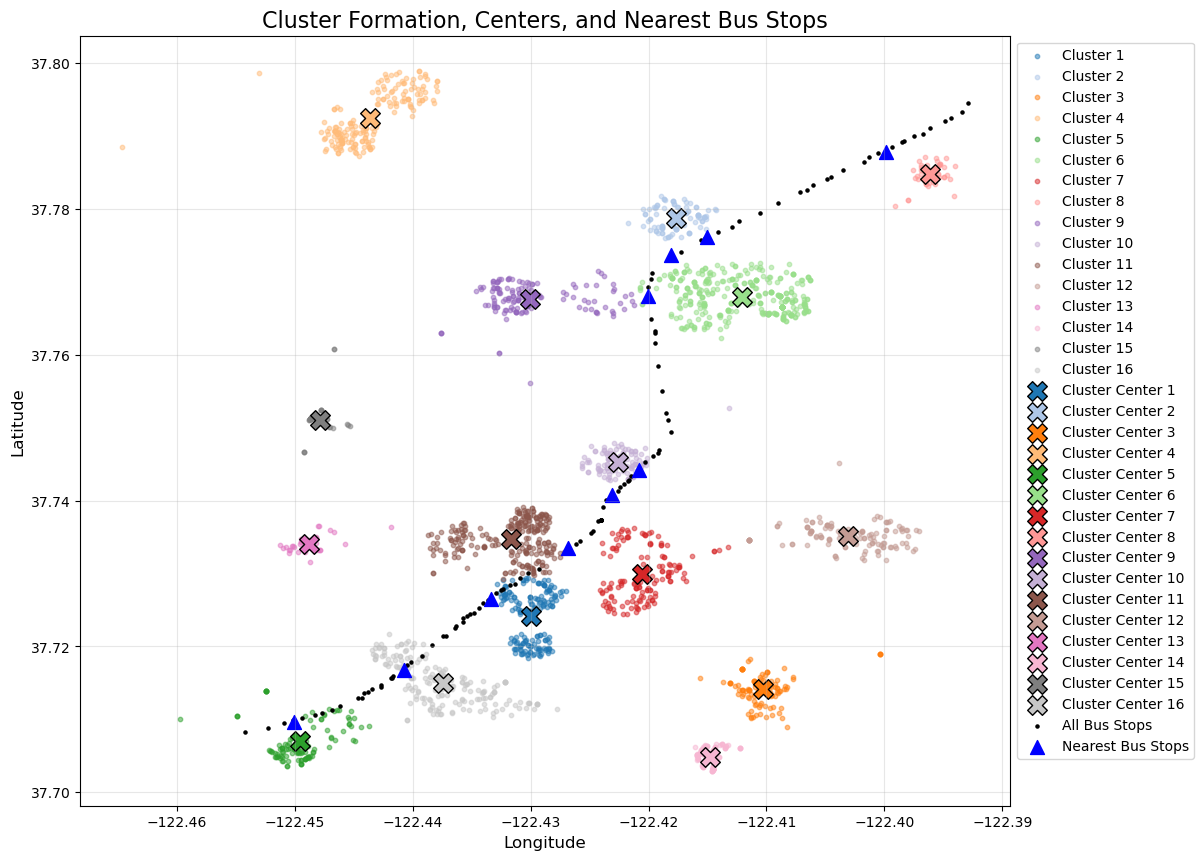

In [22]:
# Plot the clusters, cluster centers
fig, ax = plt.subplots(figsize=(12, 10))

# Generate colors for each cluster
colors = plt.cm.tab20(range(num_clusters))

# Scatter plot for employees with transparency to emphasize cluster centers
for cluster_id in range(num_clusters):
    cluster_points = employee_coords[kmeans.labels_ == cluster_id]
    ax.scatter(
        cluster_points[:, 0],  # Latitude
        cluster_points[:, 1],  # Longitude
        c=[colors[cluster_id]], s=10, alpha=0.5, label=f"Cluster {cluster_id+1}"
    )

# Plot cluster centers with larger size, edge color, and unique shape
for cluster_id, center in enumerate(cluster_centers):
    ax.scatter(
        center[0],  # Latitude
        center[1],  # Longitude
        c=[colors[cluster_id]], edgecolors='black', marker='X', s=200, label=f"Cluster Center {cluster_id+1}"
    )

# Plot all bus stops
ax.scatter(
    bus_stop_coords[:, 0],  # Latitude
    bus_stop_coords[:, 1],  # Longitude
    c='black', marker='o', s=5, label='All Bus Stops'
)
# plot nearest bus stops
ax.scatter(
    optimized_stops_df['Longitude'], optimized_stops_df['Latitude'],  
    c='blue', marker='^', s=100, label='Nearest Bus Stops'
)
# Add labels, legend, and title
ax.set_title('Cluster Formation, Centers, and Nearest Bus Stops', fontsize=16)
ax.set_xlabel('Longitude', fontsize=12)  # Latitude on x-axis
ax.set_ylabel('Latitude', fontsize=12)  # Longitude on y-axis
plt.legend(fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(alpha=0.3)  # Add a light grid for better visualization
plt.show()